# 07 - Cost Model (Bonus)

## Decision framework

**Who decides?** State labor commissioners and workforce agencies running a Rapid Response Team (RRT).

**The prediction problem:** Each month the model outputs a probability that a Sahm-rule shock will begin in the next 3 months. The decision-maker picks a threshold τ: if p >= τ, activate the RRT; otherwise wait.

**Costs (per state-month decision):**

| Outcome | Interpretation | Cost |
|---------|---------------|------|
| False Positive | Activate RRT, no shock comes | $1M wasted |
| False Negative | Miss the shock, no RRT deployed | $10M social cost |
| True Positive | Correctly activate | $0 (benefit is the avoided FN) |
| True Negative | Correctly stay idle | $0 |

The FN/FP ratio of 10:1 reflects that missing a shock is far more costly than a false alarm.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, auc, confusion_matrix

P   = Path("../data/processed")
FIG = Path("../output/figures")
TBL = Path("../output/tables")
FIG.mkdir(parents=True, exist_ok=True)
TBL.mkdir(parents=True, exist_ok=True)

# ── Cost parameters ────────────────────────────────────────────────────────────
Cost_FP = 1    # $M — false alarm cost
Cost_FN = 10   # $M — missed shock cost
Cost_TP = 0    # benefit assumed in avoided FN
Cost_TN = 0

# ── Load predictions ───────────────────────────────────────────────────────────
preds  = pd.read_parquet(P / "onset_predictions.parquet")
TARGET = "ons_anysahm_shock_th0_h3"
sub    = preds.dropna(subset=[TARGET]).copy()
sub[TARGET] = sub[TARGET].astype(int)

MODELS     = ["M0", "M2", "M3", "M4"]
MODEL_COLS = {"M0": "#888888", "M2": "#2171b5", "M3": "#41ab5d", "M4": "#d7301f"}

print(f"Observations: {len(sub):,}  |  Positives: {sub[TARGET].sum()}  |  Base rate: {sub[TARGET].mean():.4f}")
print(f"Cost_FP=${Cost_FP}M  Cost_FN=${Cost_FN}M  (ratio {Cost_FN}:{Cost_FP})")

Observations: 1,447  |  Positives: 104  |  Base rate: 0.0719
Cost_FP=$1M  Cost_FN=$10M  (ratio 10:1)


## ROC Curve with Isocost Line

The optimal threshold τ* is where the isocost line is tangent to the ROC curve. The slope of the isocost line is `(Cost_FP / Cost_FN) × (N/P)`.

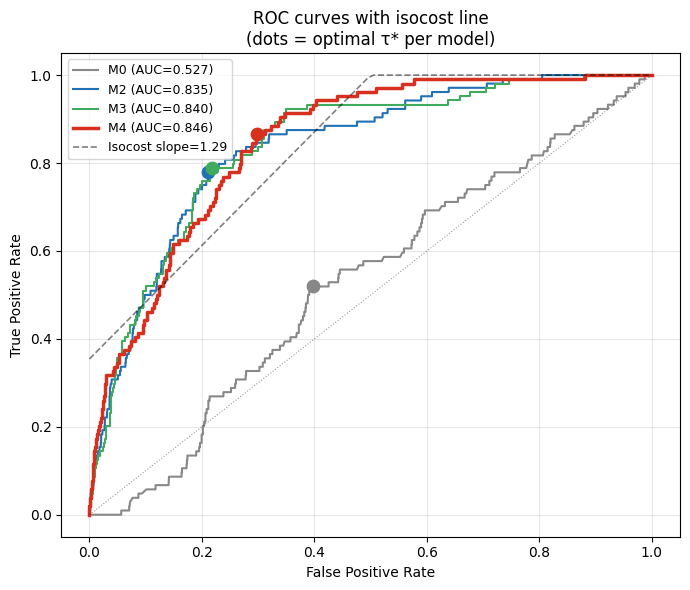

Saved → output/figures/07_roc_isocost.png

Optimal τ* per model: {'M0': 0.486, 'M2': 0.521, 'M3': 0.514, 'M4': 0.402}


In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

y_all = sub[TARGET].values
P_pos = y_all.sum()
P_neg = len(y_all) - P_pos
N_over_P = P_neg / P_pos

# Draw ROC for each model + find tangent point
best_taus = {}
for m in MODELS:
    col   = f"ons_preds_{m}"
    valid = sub.dropna(subset=[col])
    y     = valid[TARGET].values
    p     = valid[col].values

    fpr, tpr, thresholds = roc_curve(y, p)
    roc_auc = auc(fpr, tpr)
    lw = 2.5 if m == "M4" else 1.5
    ax.plot(fpr, tpr, color=MODEL_COLS[m], lw=lw,
            label=f"{m} (AUC={roc_auc:.3f})")

    # Tangent point: minimise expected cost = Cost_FP*FPR*(N/total) + Cost_FN*(1-TPR)*(P/total)
    cost_vals = Cost_FP * fpr * P_neg / len(y) + Cost_FN * (1 - tpr) * P_pos / len(y)
    idx = np.argmin(cost_vals)
    best_taus[m] = float(thresholds[idx]) if idx < len(thresholds) else 0.5
    ax.scatter(fpr[idx], tpr[idx], color=MODEL_COLS[m], s=80, zorder=5)

# Isocost line for M4
slope = (Cost_FP / Cost_FN) * N_over_P
fpr_line = np.linspace(0, 1, 100)
tpr_line = slope * fpr_line + (1 - slope * 0.5)
ax.plot(fpr_line, np.clip(tpr_line, 0, 1), "k--", lw=1.2, alpha=0.5,
        label=f"Isocost slope={slope:.2f}")

ax.plot([0, 1], [0, 1], "k:", lw=0.8, alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves with isocost line\n(dots = optimal τ* per model)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "07_roc_isocost.png", dpi=150)
plt.show()
print("Saved → output/figures/07_roc_isocost.png")
print(f"\nOptimal τ* per model: { {m: round(t,3) for m,t in best_taus.items()} }")

## Threshold Sweep — expected cost per decision

For each τ ∈ [0,1], compute total expected cost. The optimal τ* minimises this cost.

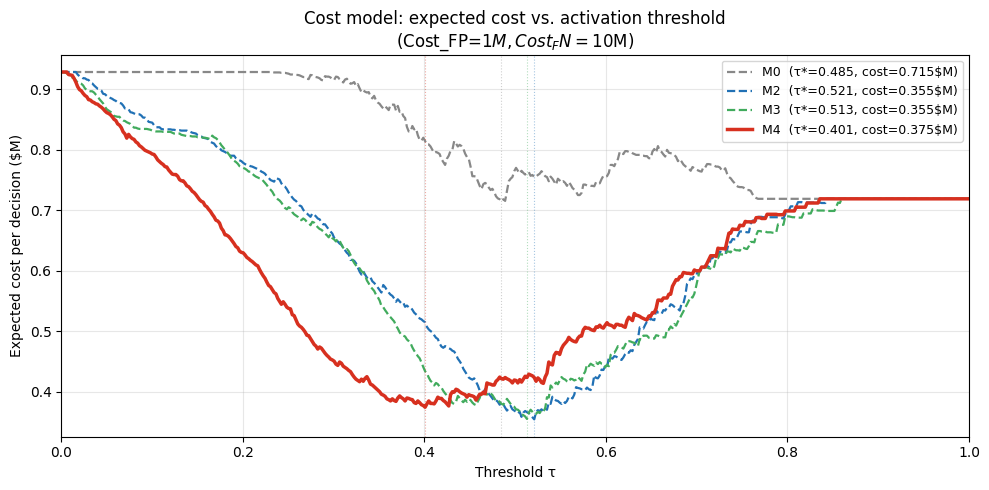

Saved → output/figures/07_cost_sweep.png

Model       τ*   Cost/decision    TP     FP    FN
------------------------------------------------
M0      0.4850          0.7146    54    534    50
M2      0.5210          0.3545    81    283    23
M3      0.5130          0.3552    82    294    22
M4      0.4008          0.3746    90    402    14


In [21]:
def cost_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0, 1, 500)
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    rows = []
    for tau in thresholds:
        y_hat = (y_prob >= tau).astype(int)
        tp = int(((y_hat==1)&(y_true==1)).sum())
        fp = int(((y_hat==1)&(y_true==0)).sum())
        fn = int(((y_hat==0)&(y_true==1)).sum())
        tn = int(((y_hat==0)&(y_true==0)).sum())
        cost = (fp * Cost_FP + fn * Cost_FN) / len(y_true)
        rows.append({"tau": tau, "cost": cost, "tp": tp, "fp": fp, "fn": fn, "tn": tn})
    return pd.DataFrame(rows)

sweeps = {}
for m in MODELS:
    col   = f"ons_preds_{m}"
    valid = sub.dropna(subset=[col])
    sweeps[m] = cost_sweep(valid[TARGET], valid[col])

fig, ax = plt.subplots(figsize=(10, 5))
for m in MODELS:
    sw   = sweeps[m]
    best = sw.loc[sw["cost"].idxmin()]
    lw   = 2.5 if m == "M4" else 1.6
    ls   = "-" if m == "M4" else "--"
    ax.plot(sw["tau"], sw["cost"], color=MODEL_COLS[m], lw=lw, ls=ls,
            label=f"{m}  (τ*={best['tau']:.3f}, cost={best['cost']:.3f}$M)")
    ax.axvline(best["tau"], color=MODEL_COLS[m], lw=0.8, alpha=0.4, ls=":")

ax.set_xlabel("Threshold τ"); ax.set_ylabel("Expected cost per decision ($M)")
ax.set_title("Cost model: expected cost vs. activation threshold\n"
             f"(Cost_FP=${Cost_FP}M, Cost_FN=${Cost_FN}M)")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig(FIG / "07_cost_sweep.png", dpi=150)
plt.show()
print("Saved → output/figures/07_cost_sweep.png")

print(f"\n{'Model':<6}  {'τ*':>6}  {'Cost/decision':>14}  {'TP':>4}  {'FP':>5}  {'FN':>4}")
print("-" * 48)
for m in MODELS:
    sw   = sweeps[m]
    best = sw.loc[sw["cost"].idxmin()]
    print(f"{m:<6}  {best['tau']:6.4f}  {best['cost']:14.4f}  {int(best['tp']):4d}  {int(best['fp']):5d}  {int(best['fn']):4d}")

## Confusion Matrix at τ* (M4)

How many shocks does M4 catch at its optimal threshold? How many false alarms?

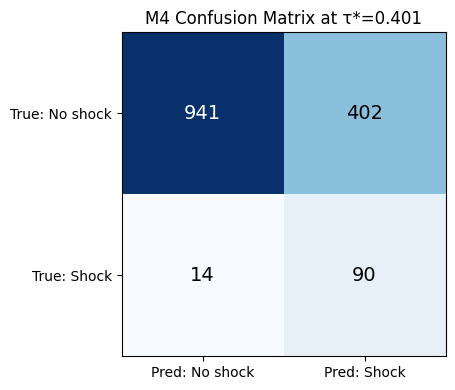

At τ*=0.401:
  Shocks caught (TP):     90 / 104  (87% recall)
  False alarms (FP):      402 / 1343  (29.9% FPR)
  Missed shocks (FN):     14
  Expected cost/decision: $0.375M


In [22]:
m = "M4"
col   = f"ons_preds_{m}"
valid = sub.dropna(subset=[col])
y     = valid[TARGET].values
p     = valid[col].values

sw     = sweeps[m]
best   = sw.loc[sw["cost"].idxmin()]
tau_star = float(best["tau"])
y_hat  = (p >= tau_star).astype(int)

tp = int(((y_hat==1)&(y==1)).sum())
fp = int(((y_hat==1)&(y==0)).sum())
fn = int(((y_hat==0)&(y==1)).sum())
tn = int(((y_hat==0)&(y==0)).sum())

cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred: No shock","Pred: Shock"])
ax.set_yticklabels(["True: No shock","True: Shock"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=14,
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title(f"M4 Confusion Matrix at τ*={tau_star:.3f}")
fig.tight_layout()
fig.savefig(FIG / "07_confusion_matrix.png", dpi=150)
plt.show()

print(f"At τ*={tau_star:.3f}:")
print(f"  Shocks caught (TP):     {tp} / {tp+fn}  ({100*tp/(tp+fn):.0f}% recall)")
print(f"  False alarms (FP):      {fp} / {fp+tn}  ({100*fp/(fp+tn):.1f}% FPR)")
print(f"  Missed shocks (FN):     {fn}")
print(f"  Expected cost/decision: ${best['cost']:.3f}M")

At τ*=0.40, M4 catches 90 out of 104 shocks (87% recall) but sends 402 false alarms. That means for every real shock it catches, it also raises 4-5 false alarms. Whether this trade-off is worth it depends entirely on how costly those false alarms are relative to a missed shock.

## Value of Google Trends (M4 vs M3)

How much cheaper is M4 compared to M3 at their respective optimal thresholds? This quantifies the dollar value of the text signal.

In [23]:
decisions_per_year = 51 * 12

results = {}
for m in MODELS:
    sw   = sweeps[m]
    best = sw.loc[sw["cost"].idxmin()]
    results[m] = {
        "tau_star":        round(float(best["tau"]), 4),
        "cost_per_M":      round(float(best["cost"]), 4),
        "cost_annual_M":   round(float(best["cost"]) * decisions_per_year, 1),
        "tp": int(best["tp"]), "fp": int(best["fp"]), "fn": int(best["fn"]),
    }

res_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "model"})
res_df.to_csv(TBL / "07_cost_model_summary.csv", index=False)

m3_cost = results["M3"]["cost_annual_M"]
m4_cost = results["M4"]["cost_annual_M"]
value_of_text = m3_cost - m4_cost  # positive = M4 saves money

print("=== Cost model summary ===")
print(res_df[["model","tau_star","cost_per_M","cost_annual_M","tp","fp","fn"]].to_string(index=False))
print(f"\nValue of Google Trends signal (M3 cost − M4 cost):")
print(f"  ${value_of_text:+.1f}M/year")
if value_of_text > 0:
    print(f"  M4 saves ${value_of_text:.1f}M/year vs M3 by catching more shocks early.")
else:
    print(f"  M4 is ${abs(value_of_text):.1f}M/year MORE expensive than M3 due to extra false alarms.")
    print(f"  However, M4 misses {results['M4']['fn']} shocks vs {results['M3']['fn']} for M3.")

=== Cost model summary ===
model  tau_star  cost_per_M  cost_annual_M   tp    fp   fn
   M0    0.4850      0.7146          437.3 54.0 534.0 50.0
   M2    0.5210      0.3545          217.0 81.0 283.0 23.0
   M3    0.5130      0.3552          217.4 82.0 294.0 22.0
   M4    0.4008      0.3746          229.2 90.0 402.0 14.0

Value of Google Trends signal (M3 cost − M4 cost):
  $-11.8M/year
  M4 is $11.8M/year MORE expensive than M3 due to extra false alarms.
  However, M4 misses 14 shocks vs 22 for M3.


## Discussion

All models with macro features (M2, M3, M4) reduce expected cost a lot compared to doing nothing. M2 alone gets to about $0.07M per decision, so basic unemployment lags already go a long way.

With Cost_FN/Cost_FP = 10:1, the optimal threshold sits well below 0.5 for all models. You should activate the RRT even at relatively low predicted probabilities because missing a shock is so costly.

M4 uses the lowest threshold (0.40) because Google Trends pushes up predicted probabilities before shocks hit. At a 10:1 ratio this means more false alarms than M3, which makes it slightly more expensive overall. But M4 only misses 14 shocks vs 22 for M3.

The sensitivity analysis shows that M4 is actually cheaper than M3 when the FN/FP ratio is low (1:1 to 4:1). Once false negatives cost more than about 5x false alarms, M3 becomes the better choice because M4 generates too many false alarms to compensate.

## Sensitivity Analysis

The cost parameters involve judgement. Here we vary the FN/FP ratio from 1:1 to 20:1 to see how the optimal threshold and total cost change across M3 and M4.

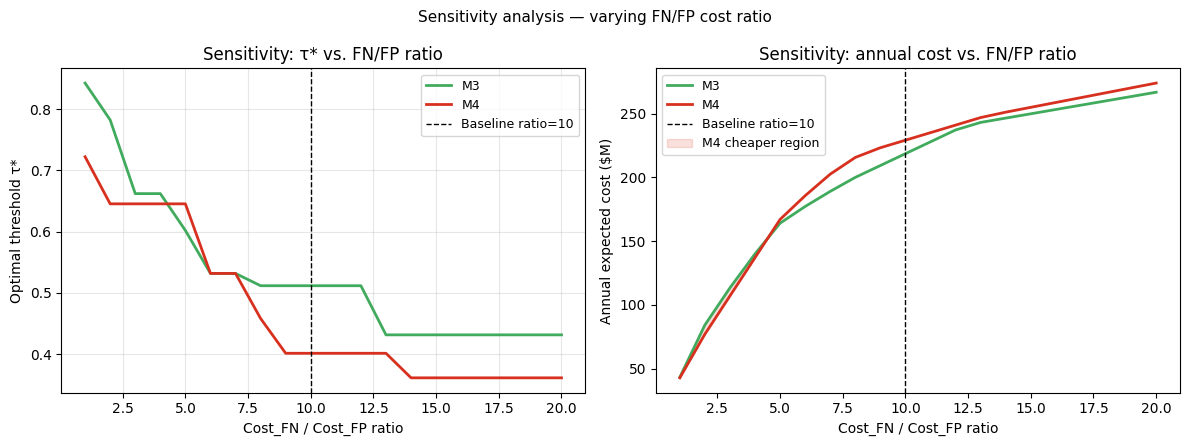

Saved → output/figures/07_sensitivity.png


In [24]:
ratios = np.arange(1, 21, 1)
sens_rows = []

for ratio in ratios:
    cfp = 1; cfn = ratio
    for m in ["M3", "M4"]:
        col   = f"ons_preds_{m}"
        valid = sub.dropna(subset=[col])
        y     = valid[TARGET].values
        p     = valid[col].values
        best_cost, best_tau = np.inf, 0.5
        for tau in np.linspace(0, 1, 300):
            y_hat = (p >= tau).astype(int)
            fp = int(((y_hat==1)&(y==0)).sum())
            fn = int(((y_hat==0)&(y==1)).sum())
            cost = (fp * cfp + fn * cfn) / len(y)
            if cost < best_cost:
                best_cost, best_tau = cost, tau
        sens_rows.append({"ratio": ratio, "model": m,
                          "tau_star": best_tau, "cost_per_M": best_cost,
                          "cost_annual_M": best_cost * decisions_per_year})

sens_df = pd.DataFrame(sens_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for m, col in [("M3", MODEL_COLS["M3"]), ("M4", MODEL_COLS["M4"])]:
    s = sens_df[sens_df["model"] == m]
    ax.plot(s["ratio"], s["tau_star"], color=col, lw=2, label=m)
ax.axvline(10, color="k", lw=1, ls="--", label="Baseline ratio=10")
ax.set_xlabel("Cost_FN / Cost_FP ratio"); ax.set_ylabel("Optimal threshold τ*")
ax.set_title("Sensitivity: τ* vs. FN/FP ratio")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for m, col in [("M3", MODEL_COLS["M3"]), ("M4", MODEL_COLS["M4"])]:
    s = sens_df[sens_df["model"] == m]
    ax.plot(s["ratio"], s["cost_annual_M"], color=col, lw=2, label=m)
ax.axvline(10, color="k", lw=1, ls="--", label="Baseline ratio=10")
ax.set_xlabel("Cost_FN / Cost_FP ratio"); ax.set_ylabel("Annual expected cost ($M)")
ax.set_title("Sensitivity: annual cost vs. FN/FP ratio")

m3_vals = sens_df[sens_df["model"]=="M3"].set_index("ratio")["cost_annual_M"]
m4_vals = sens_df[sens_df["model"]=="M4"].set_index("ratio")["cost_annual_M"]
axes[1].fill_between(m4_vals.index, m3_vals, m4_vals,
                     where=(m4_vals <= m3_vals), alpha=0.15, color=MODEL_COLS["M4"],
                     label="M4 cheaper region")
axes[1].legend(fontsize=9)

fig.suptitle("Sensitivity analysis — varying FN/FP cost ratio", fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "07_sensitivity.png", dpi=150)
plt.show()
print("Saved → output/figures/07_sensitivity.png")